In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import rebound
import numpy as np
from matplotlib.animation import FuncAnimation
import glob

In [ ]:
sa= rebound.Simulationarchive("/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Sim_Archives/11031213-901-91241_sim.bin")


/mnt/home/monkhayd/Software/miniconda3/envs/comets/lib/python3.12/site-packages/rebound/simulationarchive.py:95: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)


In [26]:
files=glob.glob("/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Sim_Archives/11031213-901-*_sim.bin")

In [27]:
tmax_arr=[]
for f in files:
    sim=rebound.Simulation(f, snapshot=-1)
    tmax_arr.append(sim.t)

/mnt/home/monkhayd/Software/miniconda3/envs/comets/lib/python3.12/site-packages/rebound/simulation.py:148: RuntimeWarning: The binary file seems to be corrupted. An attempt has been made to read the uncorrupted parts of it.
  warnings.warn(message, RuntimeWarning)


In [28]:
tmax_arr

[88112.02556406693,
 83072.01050050932,
 89438.01709792328,
 76401.00009239212,
 90787.00597177816,
 77667.02630472863,
 84823.02601181818,
 75924.00454143046,
 93087.01671835597,
 76499.02066788988,
 86633.00820690375,
 78248.0176409279,
 88021.00652707073,
 85683.01163746655,
 79891.02427674364,
 83362.02734751582,
 78224.00594627493,
 88439.00076632337,
 79167.02434325965,
 88212.02164629169,
 79861.01107018733,
 82251.01137330211,
 78072.00481738377,
 75128.014742628,
 81275.00188816451,
 82482.00435262178,
 71924.00775975302,
 73012.01011849155,
 79252.02415400103,
 77669.01248365741,
 86318.00502207158,
 79167.00428914113,
 90720.00284520574,
 84049.00137808145,
 89916.02630707278,
 79712.00785781081,
 84097.01665673846,
 82073.00543451725,
 89990.00189139634,
 80910.005107241,
 86223.0070623838,
 84589.01272852044,
 86419.00680224168,
 86737.0050795706,
 88577.00039815696,
 84760.01907805039,
 86767.01698941021,
 79248.00809707897,
 93207.00063663194,
 85702.01538319961,
 89832.

In [20]:
np.random.randint?

Signature: np.random.randint(low, high=None, size=None, dtype=<class 'int'>)
Docstring:
randint(low, high=None, size=None, dtype=int)

Return random integers from `low` (inclusive) to `high` (exclusive).

Return random integers from the "discrete uniform" distribution of
the specified dtype in the "half-open" interval [`low`, `high`). If
`high` is None (the default), then results are from [0, `low`).

.. note::
    New code should use the `~numpy.random.Generator.integers`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
low : int or array-like of ints
    Lowest (signed) integers to be drawn from the distribution (unless
    ``high=None``, in which case this parameter is one above the
    *highest* such integer).
high : int or array-like of ints, optional
    If provided, one above the largest (signed) integer to be drawn
    from the distribution (see above for behavior if ``high=None``).
    If array-lik

In [22]:
sim= rebound.Simulation("/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Sim_Archives/11031213-901-3356767_sim.bin",snapshot=-1)

In [23]:
sim.t

74865.02516472065

In [3]:
sim.t

NameError: name 'sim' is not defined

In [4]:
tmax_arr=np.logspace(2, 5, 10)
print(tmax_arr)

[   100.            215.443469      464.15888336   1000.
   2154.43469003   4641.58883361  10000.          21544.34690032
  46415.88833613 100000.        ]


In [5]:
times = np.linspace(50000, 62000, 1000)

particle_x = np.empty(len(times))
particle_y = np.empty(len(times))

planet_x = np.empty(len(times))
planet_y = np.empty(len(times))

for i, t in enumerate(times):
    sim = sa.getSimulation(t, mode="exact")
    particle = sim.particles[2]
    planet=sim.particles[1]

    particle_x[i] = particle.x
    particle_y[i] = particle.y

    planet_x[i] = particle.x
    planet_y[i] = particle.y

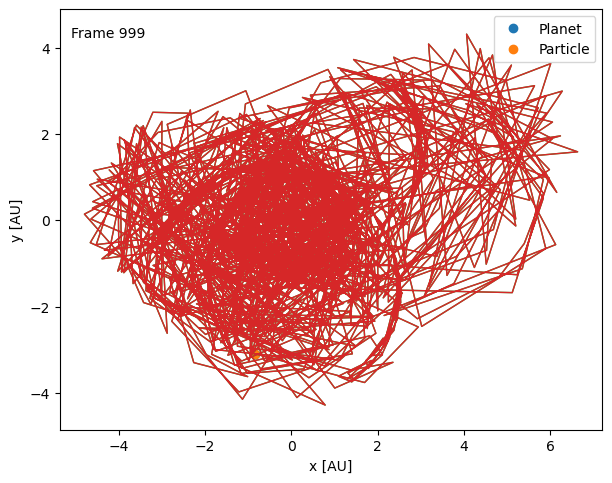

In [11]:


planet_x = np.asarray(planet_x)
planet_y = np.asarray(planet_y)
particle_x = np.asarray(particle_x)
particle_y = np.asarray(particle_y)

if not (
    len(planet_x)
    == len(planet_y)
    == len(particle_x)
    == len(particle_y)
):
    raise ValueError("All position arrays must have the same length.")

fig, ax = plt.subplots(figsize=(7, 7))

# Set fixed limits so the plot does not jump between frames.
all_x = np.concatenate([planet_x, particle_x])
all_y = np.concatenate([planet_y, particle_y])

padding = 0.05 * max(
    np.ptp(all_x),
    np.ptp(all_y),
    1.0
)

ax.set_xlim(all_x.min() - padding, all_x.max() + padding)
ax.set_ylim(all_y.min() - padding, all_y.max() + padding)
ax.set_aspect("equal")

ax.set_xlabel("x [AU]")
ax.set_ylabel("y [AU]")

planet_point, = ax.plot([], [], marker="o", linestyle="", label="Planet")
particle_point, = ax.plot([], [], marker="o", linestyle="", label="Particle")

planet_trail, = ax.plot([], [], linewidth=1)
particle_trail, = ax.plot([], [], linewidth=1)

time_text = ax.text(
    0.02,
    0.96,
    "",
    transform=ax.transAxes,
    va="top"
)

ax.legend()


def init():
    planet_point.set_data([], [])
    particle_point.set_data([], [])
    planet_trail.set_data([], [])
    particle_trail.set_data([], [])
    time_text.set_text("")

    return (
        planet_point,
        particle_point,
        planet_trail,
        particle_trail,
        time_text,
    )


def update(frame):
    planet_point.set_data([planet_x[frame]], [planet_y[frame]])
    particle_point.set_data([particle_x[frame]], [particle_y[frame]])

    planet_trail.set_data(
        planet_x[:frame + 1],
        planet_y[:frame + 1]
    )
    particle_trail.set_data(
        particle_x[:frame + 1],
        particle_y[:frame + 1]
    )

    time_text.set_text(f"Frame {frame}")

    return (
        planet_point,
        particle_point,
        planet_trail,
        particle_trail,
        time_text,
    )


animation = FuncAnimation(
    fig,
    update,
    frames=len(planet_x),
    init_func=init,
    interval=30,   # milliseconds between frames
    blit=True,
)

animation.save(
    "/mnt/home/monkhayd/Simulations/Ejection_modeling/Mass_Fraction/Outputs/Visualizations/archive_animation.gif",
    writer="pillow",
    fps=20,
    dpi=120,
)

In [6]:
5*(0.0094955/(3))**(1/3)

0.734123058790719

In [3]:
3.00274e-6*np.logspace(2, 3.5, 5)

array([0.00030027, 0.00071206, 0.00168856, 0.00400422, 0.0094955 ])

In [7]:
a=4**(2/3)

In [8]:
a

2.5198420997897464